# Friedland 2026 NW weak-magnetism comparison

Three charged-current treatments on the same NW outflow:

1. **Friedland luminosity tweak** — the $L_{\bar\nu_e} = L_{\nu_e}/1.22$ rescaling trick, weak magnetism off.
2. **Weak magnetism, first order** — SkyNet's explicit [Horowitz (2002)](https://doi.org/10.1103/PhysRevD.65.043001) correction, Eqs. (24)/(25), linear in $e = E_\nu/M$ (the previous result).
3. **Weak magnetism, all orders** — the exact Horowitz correction, Eq. (22), to all orders in $e$. The first-order form goes negative for $\bar\nu_e$ above ~50 MeV (and is clamped); the all-orders factor stays positive.

The first-order curve is drawn de-emphasized (light, dashed) next to the all-orders curve on every plot so the before/after is easy to read. All runs use the no-GR (NW) setup from [Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067), following the earlier νp-process work in [Friedland, Mukhopadhyay, and Patwardhan (2025)](https://doi.org/10.1088/1475-7516/2025/02/005).

Single real tracer trajectory (NW outflow, $t_{\rm launch} = 2.5$ s) from [Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067). Plot is final $Y(A)$ for one trajectory, not the averaged $\langle Y_A\rangle$ from Fig. 10 yet.

In [1]:
import os
import concurrent.futures
import subprocess
import textwrap

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (9.0, 5.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

trajectory = "trajectories/NW_t0_2.5s.txt"
vp_process = os.environ.get("SKYNET_VP_PROCESS", "../../build/examples/vp-process-friedland/vp_process")
run_label = os.environ.get("SKYNET_RUN_LABEL", "wm_comparison")
output_dir = os.path.join("runs", run_label)
os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(trajectory):
    raise FileNotFoundError(trajectory)
if not os.path.exists(vp_process):
    raise FileNotFoundError(
        f"Missing {vp_process}. Build the example first, e.g. `cmake --preset pardiso && cmake --build build`."
    )

trajectory, vp_process, output_dir

('trajectories/NW_t0_2.5s.txt',
 '../../build/examples/vp-process-friedland/vp_process',
 'runs/wm_comparison')

## Run the three no-GR cases

Parameters from [Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067):

| Parameter | Symbol | Value | Source |
|---|---|---|---|
| Electron fraction (equilibrium) | $Y_{e0}$ | 0.6 | NDO equilibrium expression |
| Electron-neutrino luminosity at 1 s | $L_{\nu_e}(1\,\text{s})$ | $7\times10^{51}$ erg/s | Table 1 |
| Neutrino temperature | $T_{\nu_e}$ | 2.67 MeV | Table 1 |
| Antineutrino temperature | $T_{\bar\nu_e}$ | 3.39 MeV | Table 1 |
| Neutrino degeneracy | $\eta_{\nu_e}$ | 2.1 | Table 1 |
| Antineutrino degeneracy | $\eta_{\bar\nu_e}$ | 1.5 | Table 1 |
| Luminosity decay reference time | $t_0$ | 1 s | Eq. 5.5 text |
| Luminosity decay timescale | $t_d$ | 3 s | Eq. 5.5 text |
| Density tail | $\rho \propto t^{-2}$ | — | Appendix G |

$Y_e$ is not in the tracer file, so it is passed explicitly as the proton-rich equilibrium value the paper sets from its neutrino-driven-outflow (NDO) expression.

Step control uses the adaptive floor `--smallest-y-dt 1e-12` with a loose `--max-dt 1e8` — **not** a tight cap. The heavy p-nuclei ($A \gtrsim 90$, $Y \sim 10^{-9}$) sit below SkyNet's default dt-control floor, so the controller can't see them and steps over their production; lowering the floor to `1e-12` brings them under step-error control. The loose cap then just lets dt grow through the frozen tail to $t_{\rm end}=10^9$ s (a tight cap would be ~$10^{10}$ steps). See the convergence cell at the bottom.

- **tweak** (`--no-wm-recoil --lbar-ratio 1/1.22`): antineutrino luminosity scaled to approximate weak magnetism, equal temperatures.
- **first** (`--wm-mode first`): equal luminosities, first-order [Horowitz (2002)](https://doi.org/10.1103/PhysRevD.65.043001) Eq. (24/25) correction.
- **exact** (`--wm-mode exact`): equal luminosities, all-orders Horowitz Eq. (22) correction.

In [2]:
# Integrate to ~10^9 s (decay to stability) to match the paper (App. G), so Y(A) is directly
# comparable to their Fig. 5. Converged step control = the ADAPTIVE floor --smallest-y-dt 1e-12
# with a LOOSE --max-dt (1e8): the low floor makes the controller resolve the trace p-nuclei
# (A >= 90, Y ~ 1e-9) in the active window, while the loose cap lets dt grow through the frozen
# tail (a tight cap to t_end=1e9 s would be ~1e10 steps).
t_end = os.environ.get("SKYNET_T_END", "1e9")
max_dt = os.environ.get("SKYNET_MAX_DT", "1e8")
smallest_y_dt = os.environ.get("SKYNET_SMALLEST_Y_DT", "1e-12")

COMMON_ARGS = [
    "--ye", "0.6",
    "--no-gr",
    "--L0", "7e51",
    "--T-nue", "2.6649665550",
    "--T-nuebar", "3.3917199590",
    "--eta-nue", "2.1003526050",
    "--eta-nuebar", "1.4947296660",
    "--tau-d", "3.0",
    "--t-ref", "1.0",
    "--t-end", t_end,
    "--max-dt", max_dt,
    "--smallest-y-dt", smallest_y_dt,
    "--rho-slope", "-2.0",
]

# Three corrections, all at equal luminosities except the tweak:
#   tweak  -- Friedland's L_nuebar = L_nue/1.22 approximation, weak magnetism off
#   first  -- Horowitz Eq.(24/25), first order in e = E_nu/M
#   exact  -- Horowitz Eq.(22), all orders in e
# first-order is drawn de-emphasized (dashed, light) next to the all-orders curve so
# the before/after is readable on every plot.
cases = {
    "friedland_lbar_tweak": {
        "label": "Friedland luminosity tweak",
        "color": "black",
        "ls": "-",
        "lw": 1.6,
        "prefix": os.path.join(output_dir, "friedland_lbar_tweak"),
        "wm_state": "none",
        "lbar_ratio_label": "0.819672",
        "args": ["--no-wm-recoil", "--lbar-ratio", f"{1.0 / 1.22:.12f}"],
    },
    "weak_magnetism": {
        "label": "Weak magnetism (first order)",
        "color": "#ef9a9a",
        "ls": "--",
        "lw": 1.6,
        "prefix": os.path.join(output_dir, "weak_magnetism"),
        "wm_state": "first",
        "lbar_ratio_label": "1.000000",
        "args": ["--lbar-ratio", "1.0", "--wm-mode", "first"],
    },
    "weak_magnetism_exact": {
        "label": "Weak magnetism (all orders)",
        "color": "#c62828",
        "ls": "-",
        "lw": 2.3,
        "prefix": os.path.join(output_dir, "weak_magnetism_exact"),
        "wm_state": "exact",
        "lbar_ratio_label": "1.000000",
        "args": ["--lbar-ratio", "1.0", "--wm-mode", "exact"],
    },
}

def completed_output(case):
    prefix = case["prefix"]
    h5_path = f"{prefix}.h5"
    stdout_path = f"{prefix}.stdout"
    if not os.path.exists(h5_path) or not os.path.exists(stdout_path):
        return False
    with open(stdout_path, errors="replace") as f:
        stdout_text = f.read()
    expected = [
        "Finished evolution",
        "GR blueshift: off",
        f"WM/recoil: {case['wm_state']}",
        f"lbar-ratio = {case['lbar_ratio_label']}",
    ]
    return all(marker in stdout_text for marker in expected)

def run_case(case):
    prefix = case["prefix"]
    h5_path = f"{prefix}.h5"
    stdout_path = f"{prefix}.stdout"
    if completed_output(case):
        print(f"Skipping completed output: {h5_path}")
        return
    if os.path.exists(h5_path) or os.path.exists(stdout_path):
        raise RuntimeError(
            f"Found incomplete or stale output for {case['label']}. "
            f"Move {prefix}.h5/.log/.stdout aside before rerunning."
        )

    cmd = [str(vp_process), str(trajectory), str(prefix), *COMMON_ARGS, *case["args"]]
    print("Running:")
    print(textwrap.fill(" ".join(cmd), width=100, subsequent_indent="  "))
    with open(stdout_path, "w") as stdout_file:
        result = subprocess.run(cmd, text=True, stdout=stdout_file, stderr=subprocess.STDOUT)
    with open(stdout_path, errors="replace") as stdout_file:
        tail = stdout_file.read()[-4000:]
    print(tail)
    if result.returncode != 0:
        raise subprocess.CalledProcessError(result.returncode, cmd)

with concurrent.futures.ThreadPoolExecutor(max_workers=len(cases)) as executor:
    futures = {executor.submit(run_case, case): name for name, case in cases.items()}
    for future in concurrent.futures.as_completed(futures):
        future.result()

Running:
../../build/examples/vp-process-friedland/vp_process trajectories/NW_t0_2.5s.txt
  runs/wm_comparison/friedland_lbar_tweak --ye 0.6 --no-gr --L0 7e51 --T-nue 2.6649665550 --T-nuebar
  3.3917199590 --eta-nue 2.1003526050 --eta-nuebar 1.4947296660 --tau-d 3.0 --t-ref 1.0 --t-end 1e9
  --max-dt 1e8 --smallest-y-dt 1e-12 --rho-slope -2.0 --no-wm-recoil --lbar-ratio 0.819672131148
Running:
../../build/examples/vp-process-friedland/vp_process trajectories/NW_t0_2.5s.txt
  runs/wm_comparison/weak_magnetism --ye 0.6 --no-gr --L0 7e51 --T-nue 2.6649665550 --T-nuebar
  3.3917199590 --eta-nue 2.1003526050 --eta-nuebar 1.4947296660 --tau-d 3.0 --t-ref 1.0 --t-end 1e9
  --max-dt 1e8 --smallest-y-dt 1e-12 --rho-slope -2.0 --lbar-ratio 1.0 --wm-mode first
Running:
../../build/examples/vp-process-friedland/vp_process trajectories/NW_t0_2.5s.txt
  runs/wm_comparison/weak_magnetism_exact --ye 0.6 --no-gr --L0 7e51 --T-nue 2.6649665550 --T-nuebar
  3.3917199590 --eta-nue 2.1003526050 --eta-nueba

.9760e+08  1.1845e+07  na22   0   2  3.4601e-06  8.8569e-14  5.0310e-01  4.8850e-15  1.8534e-45  1.4640e-02
 5148  7.0945e+08  1.1845e+07  na22   0   2  3.4215e-06  8.5637e-14  5.0310e-01  4.8850e-15  0.0000e+00  1.4640e-02
 5149  7.2129e+08  1.1845e+07  na22   0   2  3.3839e-06  8.2847e-14  5.0310e-01  4.8850e-15  8.6238e-45  1.4640e-02
# [2026-06-05 @ 03:36:11 PM]
# num    time [s]      dt [s] limit #fl #NR   temp [GK]   rho [cgs]          Ye    mass - 1        X(n)        X(p)
 5150  7.3313e+08  1.1845e+07  na22   0   2  3.3474e-06  8.0192e-14  5.0310e-01  5.3291e-15  1.2133e-44  1.4640e-02
 5151  7.4498e+08  1.1845e+07  na22   0   2  3.3118e-06  7.7662e-14  5.0310e-01  4.8850e-15  0.0000e+00  1.4640e-02
 5152  7.5682e+08  1.1845e+07  na22   0   2  3.2771e-06  7.5250e-14  5.0310e-01  4.6629e-15  5.6601e-45  1.4640e-02
 5153  7.6867e+08  1.1845e+07  na22   0   2  3.2434e-06  7.2949e-14  5.0310e-01  5.1070e-15  5.9008e-46  1.4640e-02
 5154  7.8051e+08  1.1845e+07  na22   0   2  3.2105

0000e+00  1.5744e-02
 5153  6.8654e+08  1.1845e+07  na22   0   2  3.4971e-06  9.1445e-14  5.0359e-01  7.9936e-15  6.8016e-45  1.5744e-02
 5154  6.9839e+08  1.1845e+07  na22   0   2  3.4575e-06  8.8370e-14  5.0359e-01  8.2157e-15  0.0000e+00  1.5744e-02
 5155  7.1023e+08  1.1845e+07  na22   0   2  3.4189e-06  8.5447e-14  5.0359e-01  7.9936e-15  0.0000e+00  1.5744e-02
 5156  7.2208e+08  1.1845e+07  na22   0   2  3.3814e-06  8.2666e-14  5.0359e-01  7.7716e-15  0.0000e+00  1.5744e-02
 5157  7.3392e+08  1.1845e+07  na22   0   2  3.3450e-06  8.0020e-14  5.0359e-01  7.3275e-15  0.0000e+00  1.5744e-02
 5158  7.4577e+08  1.1845e+07  na22   0   2  3.3095e-06  7.7498e-14  5.0359e-01  7.7716e-15  6.5198e-45  1.5744e-02
 5159  7.5761e+08  1.1845e+07  na22   0   2  3.2749e-06  7.5093e-14  5.0359e-01  7.7716e-15  0.0000e+00  1.5744e-02
 5160  7.6946e+08  1.1845e+07  na22   0   2  3.2412e-06  7.2799e-14  5.0359e-01  7.3275e-15  1.0826e-44  1.5744e-02
 5161  7.8130e+08  1.1845e+07  na22   0   2  3.2083

9488e-45  1.8964e-02
 5160  6.8374e+08  1.1845e+07  na22   0   2  3.5067e-06  9.2195e-14  5.0505e-01  5.5511e-15  2.2351e-45  1.8964e-02
 5161  6.9559e+08  1.1845e+07  na22   0   2  3.4668e-06  8.9082e-14  5.0505e-01  5.1070e-15  6.1136e-45  1.8964e-02
 5162  7.0743e+08  1.1845e+07  na22   0   2  3.4280e-06  8.6124e-14  5.0505e-01  5.7732e-15  1.3468e-44  1.8964e-02
 5163  7.1928e+08  1.1845e+07  na22   0   2  3.3902e-06  8.3311e-14  5.0505e-01  5.9952e-15  1.3176e-44  1.8964e-02
 5164  7.3112e+08  1.1845e+07  na22   0   2  3.3535e-06  8.0633e-14  5.0505e-01  5.3291e-15  1.2535e-44  1.8964e-02
 5165  7.4297e+08  1.1845e+07  na22   0   2  3.3178e-06  7.8083e-14  5.0505e-01  5.9952e-15  0.0000e+00  1.8964e-02
 5166  7.5481e+08  1.1845e+07  na22   0   2  3.2830e-06  7.5651e-14  5.0505e-01  5.9952e-15  3.6108e-45  1.8964e-02
 5167  7.6666e+08  1.1845e+07  na22   0   2  3.2491e-06  7.3332e-14  5.0505e-01  5.7732e-15  4.3130e-45  1.8964e-02
 5168  7.7850e+08  1.1845e+07  na22   0   2  3.2160

In [3]:
def read_output(prefix):
    path = f"{prefix}.h5"
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    with h5py.File(path, "r") as f:
        data = {name: np.asarray(f[name]) for name in ["Time", "Temperature", "Density", "Ye", "Y", "A", "Z"]}
    data["path"] = path
    return data

def y_by_a(y, a):
    max_a = int(np.max(a))
    out = np.zeros(max_a + 1)
    np.add.at(out, a.astype(int), y)
    return np.arange(max_a + 1), out

outputs = {name: read_output(case["prefix"]) for name, case in cases.items()}

reference = outputs["friedland_lbar_tweak"]
for name, out in outputs.items():
    assert np.array_equal(reference["A"], out["A"]), f"A grid mismatch for {name}"
    assert np.array_equal(reference["Z"], out["Z"]), f"Z grid mismatch for {name}"

for name, case in cases.items():
    stdout_path = f"{case['prefix']}.stdout"
    with open(stdout_path, errors="replace") as f:
        stdout_text = f.read()
    assert "GR blueshift: off" in stdout_text, f"GR was not disabled for {name}"
    print(f"{case['label']}: {outputs[name]['path']}")

Friedland luminosity tweak: runs/wm_comparison/friedland_lbar_tweak.h5
Weak magnetism (first order): runs/wm_comparison/weak_magnetism.h5
Weak magnetism (all orders): runs/wm_comparison/weak_magnetism_exact.h5


## Entropy consistency check

The tracer carries an entropy-per-baryon column (col 5) that the driver reads and throws away — we drive the network with the tracer's $T(t)$ and $\rho(t)$, and $s$ is then whatever the Helmholtz EOS returns for the evolving composition, not an input. [Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067) lean on entropy as the parameter that sets the $\alpha$-rich freeze-out feeding triple-$\alpha$ (and Beard+2017's enhancement of it), so before trusting any of the yields it's worth confirming our $(T,\rho,Y_e)$ ingestion actually reproduces their $s(t)$ rather than just assuming it does.

I recompute $s$ from SkyNet's own EOS at every output step and overlay the tracer column. Expectation: the two should track once the parcel is in the nucleosynthesis window ($T_9\lesssim5$), and drift at the hot NSE start, where the fixed $Y_e=0.6$ + Helmholtz assumption is furthest from the tracer's actual near-PNS state — which is the regime that doesn't set the seeds anyway. That's roughly what comes out: $s_{\rm EOS}$ runs ~2.8× the tracer right at the start ($T_9\sim39$), then converges to within ~5% by $T_9\lesssim5$ and ~2% by the end of the trajectory. Good enough where it counts.

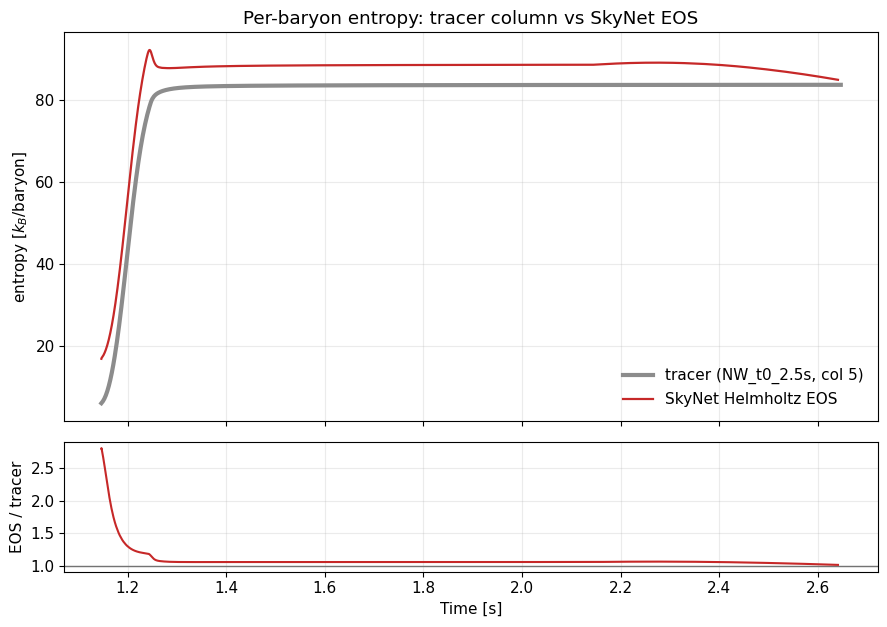

S(EOS)/S(tracer): hot NSE start = 2.80, T9<5 window median = 1.059, trajectory end = 1.015


In [4]:
# Consistency check: does SkyNet's Helmholtz EOS reproduce the tracer's entropy?
# s(t) is not a network input -- we feed T(t) and rho(t), and the entropy follows
# from the EOS and the evolving composition. Agreement validates the (T, rho, Ye)
# ingestion. SkyNet.SkyNetRoot is the compiled-in install root, same data files the
# driver uses; no extra local paths to encode.
import sys
sys.path.insert(0, os.path.abspath("../../build"))
import SkyNet

_nuclib = SkyNet.NuclideLibrary.CreateFromWebnucleoXML(
    os.path.join(SkyNet.SkyNetRoot, "data/webnucleo_nuc_v2.0.xml"))
_helm = SkyNet.HelmholtzEOS(os.path.join(SkyNet.SkyNetRoot, "data/helm_table.dat"))

# tracer columns: time[s] r[m] v[m/s] kT[J] s[kb/baryon] rho[kg/m3]
traj_cols = np.loadtxt(trajectory)
traj_t, traj_s = traj_cols[:, 0], traj_cols[:, 4]

def skynet_entropy(out):
    t, T9, rho, Y, ye = (out["Time"], out["Temperature"], out["Density"],
                         out["Y"], out["Ye"])
    # only within the tracer span (where there is an s to compare) and above the EOS
    # floor ye*rho > 1e-12 that the frozen tail eventually drops below.
    m = (t >= traj_t[0]) & (t <= traj_t[-1]) & (ye * rho > 1e-11)
    s = np.full(t.shape, np.nan)
    for i in np.where(m)[0]:
        yv = SkyNet.std_vector_double(Y[i].tolist())
        s[i] = _helm.FromTAndRho(float(T9[i]), float(rho[i]), yv, _nuclib).S()
    return s

# composition (hence entropy) barely moves across the three WM cases; check the reference.
s_sky = skynet_entropy(reference)
sel = np.isfinite(s_sky)
t_sel = reference["Time"][sel]
ratio = s_sky[sel] / np.interp(t_sel, traj_t, traj_s)

fig, (ax, axr) = plt.subplots(2, 1, sharex=True, figsize=(9.0, 6.4),
                              gridspec_kw=dict(height_ratios=[3, 1]))
ax.plot(traj_t, traj_s, color="0.55", lw=3.0, label="tracer (NW_t0_2.5s, col 5)")
ax.plot(t_sel, s_sky[sel], color="#c62828", lw=1.6, label="SkyNet Helmholtz EOS")
ax.set_ylabel("entropy [$k_B$/baryon]")
ax.set_title("Per-baryon entropy: tracer column vs SkyNet EOS")
ax.legend(frameon=False)

axr.axhline(1.0, color="0.45", lw=1.0)
axr.plot(t_sel, ratio, color="#c62828")
axr.set_ylabel("EOS / tracer")
axr.set_xlabel("Time [s]")
fig.tight_layout()
plt.show()

# the T9 < 5 window is the one that feeds 3-alpha and the vp-process
window = sel & (reference["Temperature"] < 5.0)
rw = s_sky[window] / np.interp(reference["Time"][window], traj_t, traj_s)
print(f"S(EOS)/S(tracer): hot NSE start = {ratio[0]:.2f}, "
      f"T9<5 window median = {np.median(rw):.3f}, trajectory end = {ratio[-1]:.3f}")

## Final abundance pattern

Final $Y(A)$ decayed to stability ($t_{\rm end}=10^9$ s, matching the paper), styled after [Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067) Fig. 5/10. Labels mark p-nuclide mass numbers along the top, and the thin bottom panel shows each weak-magnetism treatment relative to the luminosity tweak. These are single-trajectory values, not the mass-outflow-rate weighted $\langle Y_A\rangle$.

Three curves: the Friedland luminosity tweak (black), first-order weak magnetism (light dashed red), and all-orders weak magnetism (solid red). The grey dashed line is the **NW ($t_{\rm launch}=2.5$ s) curve from Fig. 5**, extracted from the vector paths of `YA_cases.pdf` in the arXiv:2508.02055 source — the full per-mass sawtooth (peaks and valleys), not an eyeballed envelope. Calibration was checked against the figure axes (the $y$ gridlines map to exactly $10^{-9}\ldots10^{-2}$ and the Se74 tick to $A=74$).

As expected at the few MeV energy scale ($T_{\bar\nu_e}=3.39$ MeV, $e = E_\nu/M \sim 0.01$) first-order and all-orders sit close — they differ at the few-percent level on integrated yields (see the ratio panel and the mass-fraction table). The all-orders heavy-tail ($A\gtrsim90$) yield comes out a bit *below* first-order on this trajectory.

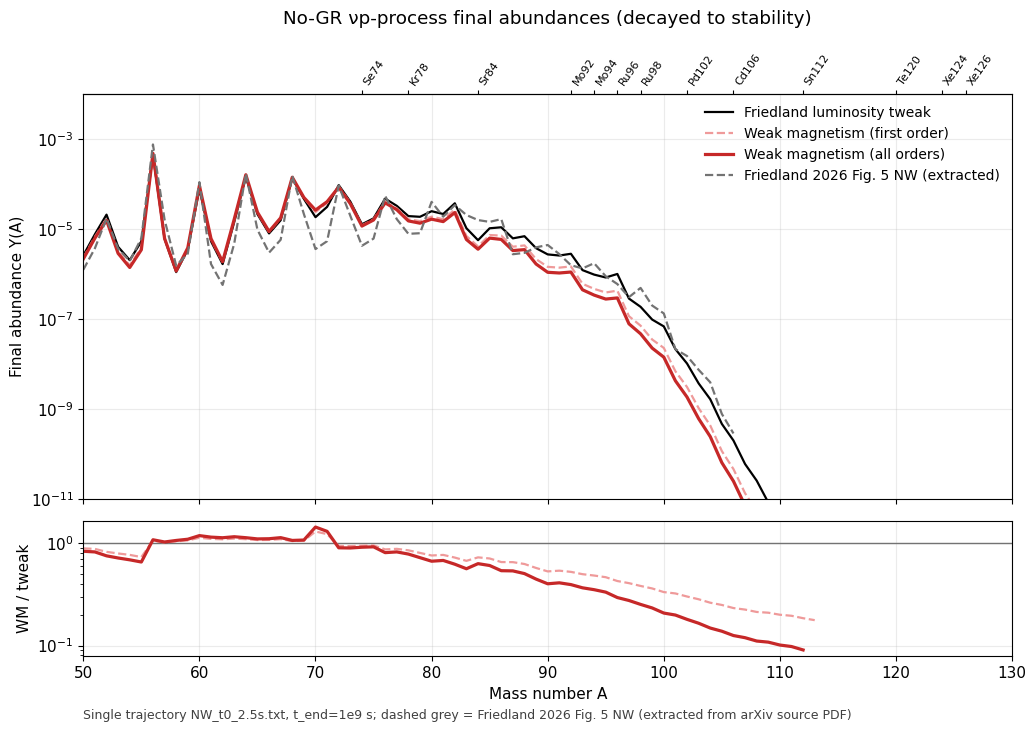

In [5]:
isotope_marks = [
    (74, "Se74"),
    (78, "Kr78"),
    (84, "Sr84"),
    (92, "Mo92"),
    (94, "Mo94"),
    (96, "Ru96"),
    (98, "Ru98"),
    (102, "Pd102"),
    (106, "Cd106"),
    (112, "Sn112"),
    (120, "Te120"),
    (124, "Xe124"),
    (126, "Xe126"),
]

# NW curve (black solid, t_launch = 2.5 s) from Friedland et al. 2026 Fig. 5, extracted from
# the vector paths of YA_cases.pdf in the arXiv:2508.02055 source (not eyeballed): the full
# per-mass sawtooth (peaks AND valleys). Calibration was validated against the figure axes —
# the y gridlines map to exactly 1e-9..1e-2 and the Se74 tick to A=74. Reference only.
fig5_nw_A = np.arange(50, 107)
fig5_nw_Y = np.array([
    1.24e-6, 3.71e-6, 1.70e-5, 3.65e-6, 1.93e-6, 6.21e-6, 7.47e-4, 1.61e-5, 1.53e-6, 2.82e-6,
    1.09e-4, 1.66e-6, 5.71e-7, 4.71e-6, 1.68e-4, 9.60e-6, 2.97e-6, 5.74e-6, 1.51e-4, 2.13e-5,
    3.57e-6, 5.34e-6, 9.19e-5, 1.95e-5, 4.22e-6, 6.09e-6, 5.42e-5, 1.65e-5, 7.77e-6, 8.02e-6,
    3.98e-5, 1.87e-5, 3.37e-5, 2.03e-5, 1.57e-5, 1.43e-5, 1.65e-5, 2.74e-6, 2.94e-6, 3.90e-6,
    4.39e-6, 2.76e-6, 1.56e-6, 1.33e-6, 1.73e-6, 8.89e-7, 5.97e-7, 3.06e-7, 4.90e-7, 1.99e-7,
    1.33e-7, 2.14e-8, 1.51e-8, 7.47e-9, 3.95e-9, 7.84e-10, 2.89e-10,
])

# top panel: Y(A); thin bottom panel: each WM treatment relative to the luminosity tweak.
fig, (ax, axr) = plt.subplots(
    2, 1, sharex=True, figsize=(10.8, 7.4),
    gridspec_kw=dict(height_ratios=[3, 1]))
abundance_floor = 1e-13

for name, case in cases.items():
    out = outputs[name]
    a_grid, y_a = y_by_a(out["Y"][-1], out["A"])
    mask = (a_grid >= 50) & (a_grid <= 130) & (y_a > abundance_floor)
    ax.plot(a_grid[mask], y_a[mask], ls=case["ls"], lw=case["lw"],
            color=case["color"], label=case["label"])

ax.plot(fig5_nw_A, fig5_nw_Y, "--", color="0.45", lw=1.6,
        label="Friedland 2026 Fig. 5 NW (extracted)")

ax.set_yscale("log")
ax.set_xlim(50, 130)
ax.set_ylim(1e-11, 1e-2)
ax.set_ylabel("Final abundance Y(A)")
ax.set_title("No-GR νp-process final abundances (decayed to stability)", pad=20)
ax.legend(frameon=False, loc="upper right", fontsize=10)

top = ax.secondary_xaxis("top")
top.set_xticks([a for a, _ in isotope_marks])
top.set_xticklabels([label for _, label in isotope_marks], rotation=55, ha="left", fontsize=8)
top.tick_params(axis="x", which="major", pad=2, length=3)

# bottom: ratio to the luminosity tweak. Same colors/styles as the top panel, no legend.
base_a, base_y = y_by_a(outputs["friedland_lbar_tweak"]["Y"][-1],
                        outputs["friedland_lbar_tweak"]["A"])
axr.axhline(1.0, color="0.45", lw=1.0)
for name in ("weak_magnetism", "weak_magnetism_exact"):
    case = cases[name]
    a_grid, y_a = y_by_a(outputs[name]["Y"][-1], outputs[name]["A"])
    assert np.array_equal(base_a, a_grid)
    ratio = np.full_like(base_y, np.nan, dtype=float)
    valid = (base_y > 1e-14) & (y_a > 1e-14)
    ratio[valid] = y_a[valid] / base_y[valid]
    mask = (base_a >= 50) & (base_a <= 130) & np.isfinite(ratio)
    axr.plot(base_a[mask], ratio[mask], ls=case["ls"], lw=case["lw"],
             color=case["color"])
axr.set_yscale("log")
axr.set_ylabel("WM / tweak")
axr.set_xlabel("Mass number A")

fig.text(
    0.10, 0.015,
    "Single trajectory NW_t0_2.5s.txt, t_end=1e9 s; dashed grey = Friedland 2026 Fig. 5 NW (extracted from arXiv source PDF)",
    ha="left",
    fontsize=9,
    color="0.25",
)

fig.subplots_adjust(left=0.10, right=0.96, bottom=0.10, top=0.86, hspace=0.08)
plt.show()

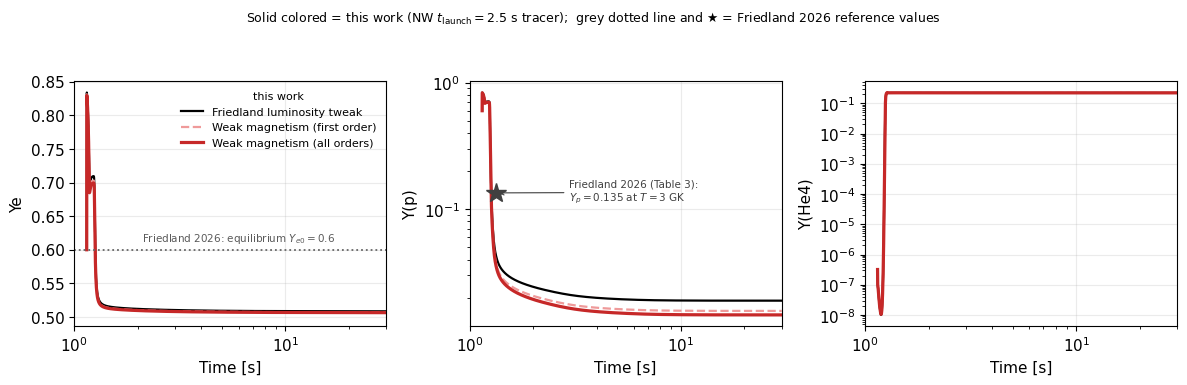

In [6]:
def isotope_index(a, z, out):
    matches = np.where((out["A"] == a) & (out["Z"] == z))[0]
    if len(matches) != 1:
        raise ValueError(f"Expected one isotope with A={a}, Z={z}, found {len(matches)}")
    return int(matches[0])

# Paper reference VALUES (Friedland 2026) — the paper has no Ye(t) or Y_p(t) curve:
#  - equilibrium electron fraction Ye0 ~ 0.6 (their NDO expression, = our input);
#  - Table 3 proton abundance Y_p = 0.1345 at T = 3 GK for NW, t_launch = 2.5 s.
ye0_ref = 0.60
yp_ref_T3 = 0.1345
out_ref = outputs["friedland_lbar_tweak"]
t_3GK = float(out_ref["Time"][np.argmin(np.abs(out_ref["Temperature"] - 3.0))])

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.9), sharex=True)
for name, case in cases.items():
    out = outputs[name]
    p_idx = isotope_index(1, 1, out)
    alpha_idx = isotope_index(4, 2, out)
    times = out["Time"]
    style = dict(color=case["color"], ls=case["ls"], lw=case["lw"])
    axes[0].plot(times, out["Ye"], label=case["label"], **style)
    axes[1].plot(times, out["Y"][:, p_idx], **style)
    axes[2].plot(times, out["Y"][:, alpha_idx], **style)

# Paper reference values drawn in grey and labelled in place.
axes[0].axhline(ye0_ref, ls=":", color="0.4", lw=1.3)
axes[0].text(6.0, ye0_ref * 1.012, "Friedland 2026: equilibrium $Y_{e0}=0.6$",
             fontsize=7.5, color="0.35", ha="center", va="bottom")
axes[1].plot([t_3GK], [yp_ref_T3], marker="*", ms=15, color="0.25", ls="none", zorder=5)
axes[1].annotate("Friedland 2026 (Table 3):\n$Y_p = 0.135$ at $T = 3$ GK",
                 xy=(t_3GK, yp_ref_T3), xytext=(0.32, 0.60), textcoords=axes[1].transAxes,
                 fontsize=7.5, color="0.25", ha="left", va="top",
                 arrowprops=dict(arrowstyle="->", color="0.25", lw=0.8))

axes[0].set_ylabel("Ye")
axes[1].set_ylabel("Y(p)")
axes[2].set_ylabel("Y(He4)")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlim(1.0, 30.0)  # zoom on the sharp early evolution; Ye/Y_p are frozen long before t_end=1e9 s
    ax.set_xlabel("Time [s]")
axes[1].set_yscale("log")
axes[2].set_yscale("log")
axes[0].legend(frameon=False, fontsize=8, title="this work", title_fontsize=8)
fig.suptitle("Solid colored = this work (NW $t_{\\rm launch}=2.5$ s tracer);  "
             "grey dotted line and ★ = Friedland 2026 reference values", fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

In [7]:
ranges = {
    "A >= 56": lambda a: a >= 56,
    "64 <= A <= 100": lambda a: (a >= 64) & (a <= 100),
    "90 <= A <= 106": lambda a: (a >= 90) & (a <= 106),
    "A > 100": lambda a: a > 100,
}

rows = []
for label, selector in ranges.items():
    row = {"range": label}
    for name, case in cases.items():
        a_grid, y_a = y_by_a(outputs[name]["Y"][-1], outputs[name]["A"])
        sel = selector(a_grid)
        row[case["label"]] = float(np.sum(a_grid[sel] * y_a[sel]))
    rows.append(row)

pd.DataFrame(rows)


,range,Friedland luminosity tweak,Weak magnetism (first order),Weak magnetism (all orders)
0,A >= 56,0.092220,0.091014,9.055594e-02
1,64 <= A <= 100,0.061038,0.057731,5.635406e-02
2,90 <= A <= 106,0.001181,0.000593,4.394983e-04
3,A > 100,0.000004,0.000001,7.189105e-07


## Not $\langle Y_A\rangle$ yet

[Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067) Fig. 10 shows the launch-time averaged abundance

$$
\langle Y_{A,Z}\rangle = \frac{\int Y_{A,Z}(t_{\mathrm{launch}})\dot M(t_{\mathrm{launch}})\,dt_{\mathrm{launch}}}{\int \dot M(t_{\mathrm{launch}})\,dt_{\mathrm{launch}}}
$$

which needs trajectories across $t_{\text{launch}} \approx 1$–7 s plus the outflow rate $\dot{M}$. I only have the one $t_{\rm launch} = 2.5$ s tracer (`NW_t0_2.5s.txt`) for now, so I'm plotting final $Y(A)$ for that single run. TODO: add more trajectories and compute $\langle Y_A\rangle$ properly.

## References

1. A. Friedland, D. J. Li, G. Lucente, I. Padilla-Gay, and A. V. Patwardhan, “νp-process in core-collapse supernovae: imprints of general relativistic effects,” Journal of Cosmology and Astroparticle Physics 2026, 067 (2026). [doi:10.1088/1475-7516/2026/02/067](https://doi.org/10.1088/1475-7516/2026/02/067); [arXiv:2508.02055](https://arxiv.org/abs/2508.02055)
2. C. J. Horowitz, “Weak magnetism for antineutrinos in supernovae,” Physical Review D 65, 043001 (2002). [doi:10.1103/PhysRevD.65.043001](https://doi.org/10.1103/PhysRevD.65.043001)
3. A. Friedland, P. Mukhopadhyay, and A. V. Patwardhan, “Successful νp-process in neutrino-driven outflows in core-collapse supernovae,” Journal of Cosmology and Astroparticle Physics 2025, 005 (2025). [doi:10.1088/1475-7516/2025/02/005](https://doi.org/10.1088/1475-7516/2025/02/005)

## Appendix: time-step convergence of the p-nuclide tail

The heavy p-nuclei ($A \gtrsim 90$) are numerically delicate. SkyNet sizes its adaptive step only from species above `SmallestYUsedForDtCalculation`; the p-nuclei sit far below that floor, so their production is outside step-error control until we either shrink `--max-dt` everywhere or lower the floor.

Below, each knob is swept incrementally and the weak-magnetism $Y(A)$ is shown approaching the converged value (dotted line). The **adaptive floor** (right panel, `--max-dt` loose) converges cleanly and cheaply — the increments shrink and the curve flattens onto the limit. The **`--max-dt` cap** (left panel, floor fixed at `1e-4`, much higher than p-nuclides in our trajectories) marches toward the *same* limit but only at very small dt. Two independent refinement paths landing on the same value is what makes the limit trustworthy.

The cell runs to $t = 10$ s (Y(A) is frozen by then) and caches its runs — first execution is a few minutes.

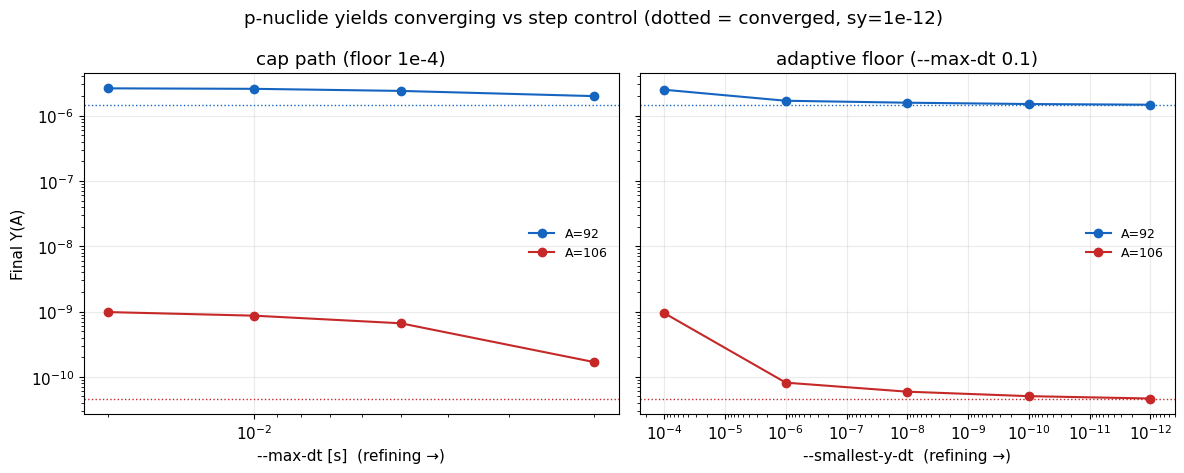

,A=92,A=106
max-dt=0.02,2.616e-06,9.811e-10
max-dt=0.01,2.572e-06,8.641e-10
max-dt=0.005,2.389e-06,6.609e-10
max-dt=0.002,1.988e-06,1.681e-10
sy=0.0001,2.490e-06,9.463e-10
sy=1e-06,1.689e-06,8.147e-11
sy=1e-08,1.576e-06,5.926e-11
sy=1e-10,1.505e-06,5.061e-11
sy=1e-12,1.469e-06,4.657e-11


In [8]:
# Sweep the two step-control knobs and watch Y(A) converge. All runs use the
# weak-magnetism case to t = 10 s (Y(A) frozen) and are cached on disk.
def _drop_flags(args, flags):
    out, skip = [], False
    for a in args:
        if skip:
            skip = False
        elif a in flags:
            skip = True
        else:
            out.append(a)
    return out

conv_t_end = "10"

def run_conv(tag, extra):
    prefix = os.path.join(output_dir, f"conv_{tag}")
    sout = f"{prefix}.stdout"
    done = (os.path.exists(f"{prefix}.h5") and os.path.exists(sout)
            and "Finished evolution" in open(sout, errors="replace").read())
    if not done:
        base = _drop_flags(COMMON_ARGS, {"--max-dt", "--smallest-y-dt", "--t-end"})
        cmd = [str(vp_process), str(trajectory), str(prefix),
               *base, "--t-end", conv_t_end, *extra, *cases["weak_magnetism"]["args"]]
        with open(sout, "w") as f:
            subprocess.run(cmd, text=True, stdout=f, stderr=subprocess.STDOUT, check=True)
    return read_output(prefix)

# Path A: refine --max-dt at a fixed coarse floor (cap controls). Path B: lower the floor at
# loose --max-dt (adaptive). Both should approach the same Y(A).
dt_sweep = [0.02, 0.01, 0.005, 0.002]
sy_sweep = [1e-4, 1e-6, 1e-8, 1e-10, 1e-12]
specs = [("dt", d, f"dt_{d:g}", ["--max-dt", f"{d:g}", "--smallest-y-dt", "1e-4"]) for d in dt_sweep]
specs += [("sy", s, f"sy_{s:g}", ["--max-dt", "0.1", "--smallest-y-dt", f"{s:g}"]) for s in sy_sweep]

res = {}
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as ex:
    futs = {ex.submit(run_conv, tag, extra): (kind, x) for kind, x, tag, extra in specs}
    for fut in concurrent.futures.as_completed(futs):
        res[futs[fut]] = fut.result()

def yA(out, a):
    return float(out["Y"][-1][out["A"] == a].sum())

# Converged reference: the finest of each path (they agree to ~25%); use sy=1e-12.
ref = {a: yA(res[("sy", 1e-12)], a) for a in (92, 106)}

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharey=True)
for ax, (kind, xs, xlabel, title) in zip(axes, [
        ("dt", dt_sweep, "--max-dt [s]  (refining →)", "cap path (floor 1e-4)"),
        ("sy", sy_sweep, "--smallest-y-dt  (refining →)", "adaptive floor (--max-dt 0.1)")]):
    for a, color in [(92, "#1565c0"), (106, "#c62828")]:
        ys = [yA(res[(kind, x)], a) for x in xs]
        ax.plot(xs, ys, "o-", color=color, label=f"A={a}")
        ax.axhline(ref[a], ls=":", color=color, lw=1.0)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.invert_xaxis()  # smaller (more refined) on the right
    ax.set_xlabel(xlabel); ax.set_title(title)
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("Final Y(A)")
fig.suptitle("p-nuclide yields converging vs step control (dotted = converged, sy=1e-12)")
fig.tight_layout()
plt.show()

# Tabulate the increments (scientific) to show the steps shrinking toward the limit.
tbl = {"A=92": {}, "A=106": {}}
for kind, x, _, _ in specs:
    key = f"max-dt={x:g}" if kind == "dt" else f"sy={x:g}"
    tbl["A=92"][key] = f"{yA(res[(kind, x)], 92):.3e}"
    tbl["A=106"][key] = f"{yA(res[(kind, x)], 106):.3e}"
pd.DataFrame(tbl)